# 유량(`Scale_Out___FT`)이 목표(`g_s_SV`)를 얼마나 따라가나`Cycle_Features_설명서.ipynb` 의 피처 정의를 그대로 쓰되, **"안정구간에서 유량이목표에서 얼마나 떨어져 있나"** 하나만 파고든 노트북이다.답하려는 질문 네 가지:1. 실제 유량이 `g_s_SV` 에서 **어느 정도 떨어져 있나** (절대값 · 비율 둘 다)2. `g_s_SV` 는 연속값이 아니라 **레시피별 이산값**이다 — 그 그룹별로 나눠 보면?3. 안정 시작 시점을 지금의 **3번째 틱**(`STEADY_TICK_MIN=2`) 대신   **2번째 / 4번째** 틱으로 바꾸면 결과가 어떻게 되나4. 안정구간에서 `(SV − FT)` 가 `SV` 의 **몇 %** 인가 — 위 조건들로 쪼개서POL(`P*`) 과 ISO(`I*`) 를 같이 본다. 두 계열은 같은 번호끼리 짝이고`Pump_BuildUp_P{n}` 과 `Pump_BuildUp_I{n}` 이 **틱 단위로 완전히 동일한** 신호다.

In [1]:
import os, sys
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from Log_Extractor import LogExtractor
from Cycle_Feature_Extractor import PUMP_MAP, STEADY_TICK_MIN, RAMP_THRESHOLD_PCT

PUMP_IDS = ["P1", "I1", "P7", "I7"]        # POL/ISO 짝 두 세트 (HD1 slot1, HD4 slot1)
START, END = "-24h", "now()"

#: 안정 시작 후보. Tick_Index 는 0부터이므로 t=2 가 "3번째 틱"(= 현재 운영값)이다.
STEADY_OPTIONS = {1: "2번째 틱", 2: "3번째 틱(현재)", 3: "4번째 틱"}
MIN_TICKS_PER_SV = 200                      # 이보다 적게 나온 SV 값은 그림에서 뺀다

# ── 색 (light surface 기준) ──────────────────────────────────────
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SEQ3 = ["#86b6ef", "#3987e5", "#184f95"]    # 안정 시작 틱 3단계 (밝을수록 이른 틱)
DIVERGING = LinearSegmentedColormap.from_list("bl_gy_rd", ["#2a78d6", "#f0efec", "#d03b3b"])
SEQ_CMAP = LinearSegmentedColormap.from_list("blues", ["#eaf2fd", "#86b6ef", "#2a78d6", "#0d366b"])


def style(ax, title=None, xlabel=None, ylabel=None):
    ax.set_facecolor(SURFACE); ax.set_axisbelow(True)
    ax.grid(True, color=GRID, lw=.8)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9)
    if title:  ax.set_title(title, color=INK, fontsize=11, pad=8)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=9.5)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=9.5)
    return ax

print(f"현재 운영값 STEADY_TICK_MIN={STEADY_TICK_MIN} → {STEADY_OPTIONS[STEADY_TICK_MIN]}부터 안정구간")

현재 운영값 STEADY_TICK_MIN=2 → 3번째 틱(현재)부터 안정구간


### 태그는 반드시 **펌프 하나씩** 받는다'틱'은 균일한 시간 간격이 아니라 **DB에 한 줄이 기록된 순간**이다. 그런데 어떤 태그를같이 요청했느냐에 따라 그 줄 수가 달라진다 — 아날로그 태그(FT/PT/SV/Hz/Ana)는 스캔마다값이 바뀌므로, 두 펌프를 한 번에 받으면 **틱이 두 배로 촘촘해져서** `Tick_Index` 가생산 코드의 것과 의미가 달라진다.(실측: 같은 6시간 구간에서 디지털 비트만 18개 요청 → 3,836행,아날로그 6개를 섞어 20개 요청 → 30,713행.)그래서 `Multi_Pump_Expansion.ipynb` 의 `tags_for()` 와 **같은 태그 구성**으로 펌프마다따로 받는다. ISO 는 같은 번호의 POL 과 head/robot/slot 을 공유하므로 `PUMP_MAP` 을그대로 쓰고, 탱크 온도만 예외다(`TK_Temp_PV_I1~I3` 만 존재).

In [2]:
def tags_for(pump_id):
    """생산 파이프라인과 동일한 태그 구성. POL/ISO 공통."""
    n, kind = int(pump_id[1:]), pump_id[0]
    info = PUMP_MAP[f"P{n}"]                # head/robot/slot 은 POL/ISO 가 공유한다
    tags = [f"Pump_BuildUp_{pump_id}", f"g_s_SV_{pump_id}", f"Scale_Out___FT_{pump_id}",
            f"Scale_Out___PT_{pump_id}", f"Ana_Out_{pump_id}", f"Hz_Out_{pump_id}",
            f"Shot_Injection_{info['head']}_P{info['slot']}", f"{info['robot']}_Robot_Num",
            "AL_Line_Bit"] + [f"{info['head']}_FOAMING_SHOT{k}" for k in range(1, 7)]
    if kind == "P":
        tags.append(f"TK_Temp_PV_{info['tank']}")   # 탱크번호 != 펌프번호
    elif n <= 3:
        tags.append(f"TK_Temp_PV_{pump_id}")        # ISO 탱크 태그는 I1~I3 만 있다
    return tags


ex = LogExtractor(env_path=os.path.join(ROOT_DIR, ".env"))
raws = {}
for pid in PUMP_IDS:
    raws[pid] = ex.get_data(start_time=START, end_time=END, target_tags=tags_for(pid))
print()
for pid, r in raws.items():
    print(f"{pid}: {r.shape[0]:,}행 x {r.shape[1]}컬럼")

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🚀 추출 시작: 2026-09-27T06:59:37.975805+00:00 ~ 2026-09-28T06:59:37.975830+00:00
   태그 16개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-27T06:49:37Z ~ 2026-09-27T12:49:37Z ... 

34344행
📦 [Chunk] 2026-09-27T12:49:37Z ~ 2026-09-27T18:49:37Z ... 

35011행
📦 [Chunk] 2026-09-27T18:49:37Z ~ 2026-09-28T00:49:37Z ... 

38080행
📦 [Chunk] 2026-09-28T00:49:37Z ~ 2026-09-28T06:49:37Z ... 

38905행
📦 [Chunk] 2026-09-28T06:49:37Z ~ 2026-09-28T06:59:37Z ... 

...

29269행
📦 [Chunk] 2026-09-27T12:49:46Z ~ 2026-09-27T18:49:46Z ... 

27519행
📦 [Chunk] 2026-09-27T18:49:46Z ~ 2026-09-28T00:49:46Z ... 

34985행
📦 [Chunk] 2026-09-28T00:49:46Z ~ 2026-09-28T06:49:46Z ... 

37837행
📦 [Chunk] 2026-09-28T06:49:46Z ~ 2026-09-28T06:59:46Z ... 

1068행
✅ 통합 완료 — 129818행 × 16컬럼

P1: 146,472행 x 17컬럼
I1: 141,395행 x 17컬럼
P7: 147,204행 x 17컬럼
I7: 129,818행 x 16컬럼


---## 1. 틱 단위 프레임 만들기사이클 구분은 설명서와 같다 — `Pump_BuildUp` 이 켜졌다 꺼지는 1회.여기서는 사이클 요약이 아니라 **틱 하나하나**가 필요하다(몇 번째 틱부터 안정인지를봐야 하므로).오차율은 **그 틱의 SV** 로 계산한다:$$\text{오차율}(t) = \frac{SV(t) - FT(t)}{SV(t)} \times 100$$첫 틱의 SV 를 사이클 전체의 목표로 삼지 **않는다.** 사이클 도중에 SV 가 바뀌는 경우가꽤 있어서(바로 아래에서 확인한다) 그러면 뒷부분 오차가 통째로 왜곡된다.

In [3]:
DAILY_EXCLUDE_START, DAILY_EXCLUDE_END = "23:50", "07:00"


def in_daily_exclude(ts):
    t = ts.time()
    return t >= pd.Timestamp(DAILY_EXCLUDE_START).time() or t <= pd.Timestamp(DAILY_EXCLUDE_END).time()


def tick_frame(raw, pump_id):
    """BuildUp ON 인 틱만 남긴 틱 단위 프레임 + 사이클 메타."""
    ft, sv, bu = f"Scale_Out___FT_{pump_id}", f"g_s_SV_{pump_id}", f"Pump_BuildUp_{pump_id}"
    df = raw.ffill().fillna(0).reset_index()
    df = df.rename(columns={df.columns[0]: "Time"})
    b = df[bu].astype(int)
    df["Cycle_ID"] = (b.diff().fillna(0) != 0).cumsum()

    on = df[b == 1].copy()
    on["Tick_Index"] = on.groupby("Cycle_ID").cumcount()
    on["SV"], on["FT"] = on[sv], on[ft]
    on["Err_Pct"] = np.where(on["SV"] > 0, (on["SV"] - on["FT"]) / on["SV"] * 100, np.nan)

    # 목표가 세팅된 지 몇 틱 지났나. 사이클 시작도 '목표 세팅'으로 친다.
    # 사이클 도중 SV 가 바뀌면 거기서 다시 0 — 그 직후는 안정이 아니라 새 목표를 쫓는 구간이다.
    changed = ((on.groupby("Cycle_ID")["SV"].diff().fillna(0) != 0) | (on["Tick_Index"] == 0))
    since, cur = [], 0
    for ch in changed.values:
        cur = 0 if ch else cur + 1
        since.append(cur)
    on["Ticks_Since_SV_Change"] = since

    g = on.groupby("Cycle_ID")
    meta = pd.DataFrame({"Start": g["Time"].first(), "N_Ticks": g.size(),
                         "SV_first": g["SV"].first(), "SV_nuniq": g["SV"].nunique(),
                         "AL": g["AL_Line_Bit"].max() if "AL_Line_Bit" in on.columns else 0})
    # 제외 규칙: 설명서 7장 + 구간 양끝의 잘린 사이클
    meta["Excluded"] = (meta["Start"].apply(in_daily_exclude) | (meta["AL"] > 0)
                        | meta.index.isin([meta.index.min(), meta.index.max()])
                        | (meta["SV_first"] <= 0))

    on = on.join(meta[["N_Ticks", "SV_nuniq", "Excluded"]], on="Cycle_ID")
    cols = ["Time", "Cycle_ID", "Tick_Index", "N_Ticks", "SV", "FT", "Err_Pct",
            "Ticks_Since_SV_Change", "SV_nuniq", "Excluded"]
    return on[cols], meta


frames = {pid: tick_frame(raws[pid], pid)[0].pipe(lambda d: d[~d["Excluded"]]) for pid in PUMP_IDS}

print(f"{'펌프':<5}{'틱':>9}{'사이클':>9}{'중앙 틱수':>10}{'SV 값 종류':>11}")
for pid, tf in frames.items():
    print(f"{pid:<5}{len(tf):>9,}{tf['Cycle_ID'].nunique():>9,}"
          f"{tf.groupby('Cycle_ID').size().median():>10.0f}{tf['SV'].nunique():>11}")

펌프           틱      사이클     중앙 틱수    SV 값 종류
P1      20,336    1,274        16         13
I1      20,326    1,274        16         12
P7      27,472    1,727        17         14
I7      27,024    1,727        17         20


---## 2. `g_s_SV` 는 연속값이 아니다 — 레시피별 이산값24시간 안에 펌프마다 10~20개의 **딱 떨어지는 SV 값**만 나온다. 제품(레시피)이 바뀔 때설정이 통째로 갈아끼워지기 때문이다. 그래서 "SV 구간을 등분"하는 게 아니라**같은 값끼리 묶는 것**이 맞는 그룹핑이다.

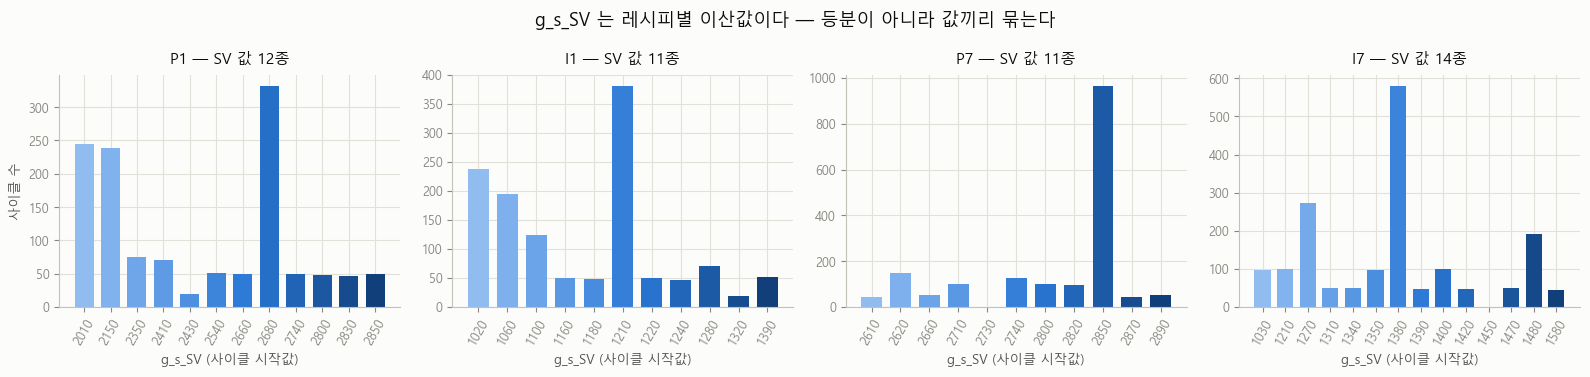

In [4]:
fig, axes = plt.subplots(1, len(PUMP_IDS), figsize=(4 * len(PUMP_IDS), 3.8))
for ax, pid in zip(np.atleast_1d(axes), PUMP_IDS):
    vc = frames[pid].groupby("Cycle_ID")["SV"].first().value_counts().sort_index()
    ax.bar([str(int(v)) for v in vc.index], vc.values, width=.72,
           color=SEQ_CMAP(np.linspace(.3, .95, len(vc))))
    style(ax, title=f"{pid} — SV 값 {len(vc)}종",
          xlabel="g_s_SV (사이클 시작값)", ylabel="사이클 수" if pid == PUMP_IDS[0] else None)
    ax.tick_params(axis="x", rotation=60)
fig.suptitle("g_s_SV 는 레시피별 이산값이다 — 등분이 아니라 값끼리 묶는다", color=INK, fontsize=13)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

### 주의 — 사이클 **도중에** SV 가 바뀐다다음 샷의 레시피 설정이 펌프가 꺼지기 전에 먼저 들어온다. 그래서 한 BuildUp 구간안에서 목표가 한 번 더 바뀌고, 펌프는 그 새 목표를 다시 쫓아간다.이걸 모르고 첫 틱 SV 를 사이클의 목표로 고정하면, 뒤쪽 틱들이 전부 "목표를 크게 벗어난상태"로 잡힌다. 아래에서 실제 빈도와 예시를 확인한다.

In [5]:
print(f"{'펌프':<5}{'사이클':>8}{'SV 도중변경':>12}{'비율':>8}   변경이 일어나는 Tick_Index (상위 5)")
for pid, tf in frames.items():
    per = tf.groupby("Cycle_ID")["SV_nuniq"].first()
    chg_tick = tf[(tf["Ticks_Since_SV_Change"] == 0) & (tf["Tick_Index"] > 0)]["Tick_Index"]
    top = ", ".join(f"{int(i)}틱({n})" for i, n in chg_tick.value_counts().head(5).items())
    print(f"{pid:<5}{len(per):>8,}{int((per > 1).sum()):>12,}{(per > 1).mean() * 100:>7.1f}%   {top}")

# 예시 하나 — 목표가 바뀌자 유량이 다시 올라간다
pid = PUMP_IDS[0]
tf = frames[pid]
cands = tf.groupby("Cycle_ID")["SV_nuniq"].first()
cid = cands[cands > 1].index[len(cands[cands > 1]) // 2]
seg = tf[tf["Cycle_ID"] == cid]
print(f"\n[예시] {pid} Cycle {cid} — 사이클 도중 SV 변경")
print(seg[["Time", "Tick_Index", "SV", "FT", "Err_Pct", "Ticks_Since_SV_Change"]]
      .round({"Err_Pct": 1}).to_string(index=False))

펌프        사이클     SV 도중변경      비율   변경이 일어나는 Tick_Index (상위 5)
P1      1,274          99    7.8%   11틱(70), 10틱(17), 12틱(12)
I1      1,274          99    7.8%   11틱(67), 12틱(16), 10틱(14), 9틱(2)
P7      1,727         912   52.8%   9틱(280), 11틱(249), 6틱(241), 10틱(218), 4틱(202)
I7      1,727         959   55.5%   9틱(302), 6틱(240), 11틱(232), 10틱(216), 4틱(212)

[예시] P1 Cycle 1327 — 사이클 도중 SV 변경
                      Time  Tick_Index     SV     FT  Err_Pct  Ticks_Since_SV_Change
2026-09-28 11:59:37.053096           0 2540.0 1373.0     45.9                      0
2026-09-28 11:59:37.587163           1 2540.0 1373.0     45.9                      1
2026-09-28 11:59:38.090196           2 2540.0 2483.0      2.2                      2
2026-09-28 11:59:38.620413           3 2540.0 2483.0      2.2                      3
2026-09-28 11:59:39.144802           4 2540.0 2512.0      1.1                      4
2026-09-28 11:59:39.680636           5 2540.0 2512.0      1.1                      5
2026-09-28 1

---## 3. 틱별 오차율 프로파일 — 실제로 어디서 평평해지나x축은 사이클 안에서의 `Tick_Index`(0 = 첫 틱), y축은 그 틱의 오차율이다.**세로 점선 셋**이 안정 시작 후보(2·3·4번째 틱 = `Tick_Index` 1·2·3)다.아래 줄은 같은 그림을 ±8% 로 확대한 것이고, 주황 선은 **SV 가 막 바뀐 틱을 뺀** 프로파일이다.

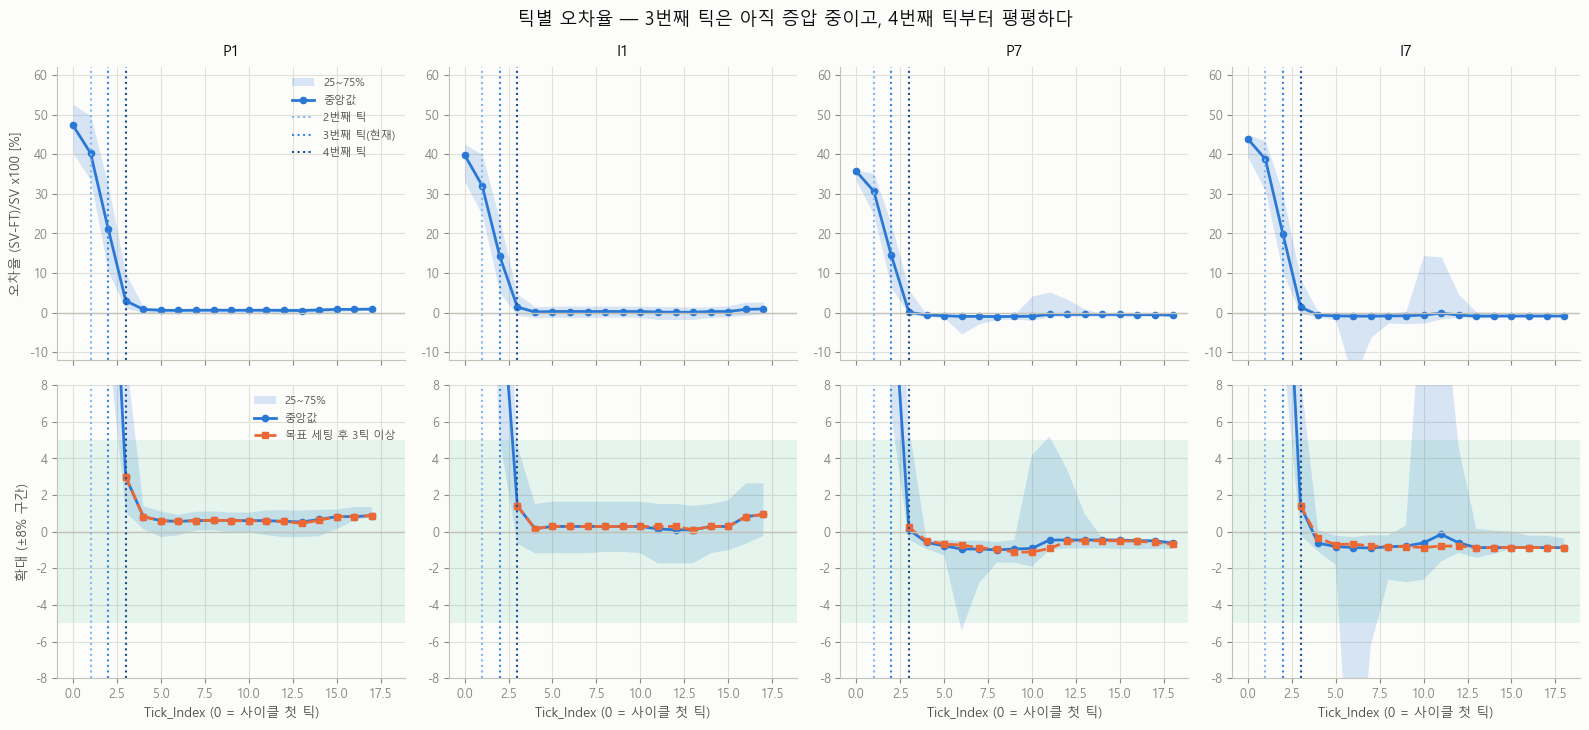

In [6]:
fig, axes = plt.subplots(2, len(PUMP_IDS), figsize=(4 * len(PUMP_IDS), 7.4), sharex=True)
for col, pid in enumerate(PUMP_IDS):
    tf = frames[pid]
    xmax = int(tf["Tick_Index"].quantile(.97))
    sub = tf[tf["Tick_Index"] <= xmax]

    for row in (0, 1):
        ax = axes[row, col]
        prof = sub.groupby("Tick_Index")["Err_Pct"]
        med, q1, q3 = prof.median(), prof.quantile(.25), prof.quantile(.75)
        ax.fill_between(med.index, q1, q3, color=BLUE, alpha=.18, lw=0, label="25~75%")
        ax.plot(med.index, med.values, color=BLUE, lw=2, marker="o", ms=4.5, label="중앙값")
        if row == 1:
            clean = sub[sub["Ticks_Since_SV_Change"] >= 3].groupby("Tick_Index")["Err_Pct"].median()
            ax.plot(clean.index, clean.values, color=ORANGE, lw=2, ls="--",
                    marker="s", ms=4, label="목표 세팅 후 3틱 이상")
            ax.set_ylim(-8, 8)
            ax.axhspan(-5, 5, color=AQUA, alpha=.10, lw=0)
        else:
            ax.set_ylim(-12, 62)
        ax.axhline(0, color=AXIS, lw=1)
        for t, c in zip(STEADY_OPTIONS, SEQ3):
            # 안정 시작 후보는 legend 로 구분한다 — x=1,2,3 이 붙어 있어 라벨을 직접 달면 겹친다
            ax.axvline(t, color=c, lw=1.5, ls=":",
                       label=STEADY_OPTIONS[t] if row == 0 else None)
        style(ax, title=f"{pid}" if row == 0 else None,
              xlabel="Tick_Index (0 = 사이클 첫 틱)" if row == 1 else None,
              ylabel=("오차율 (SV-FT)/SV x100 [%]" if row == 0 else "확대 (±8% 구간)")
                     if col == 0 else None)
        if col == 0:
            ax.legend(frameon=False, fontsize=8, labelcolor=INK2, loc="upper right")
fig.suptitle("틱별 오차율 — 3번째 틱은 아직 증압 중이고, 4번째 틱부터 평평하다", color=INK, fontsize=13)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

---## 4. 안정 시작 틱을 2 / 3 / 4번째로 바꾸면같은 데이터를 세 기준으로 자르고, 그 안의 틱들이 목표에서 얼마나 떨어져 있는지 비교한다.**안정구간을 재는 방법 두 가지**를 나란히 놓는다:| | 정의 | 의미 ||---|---|---|| **A. 사이클 기준** | `Tick_Index >= t` | 펌프가 켜지고 t틱 지남 — **현재 운영 방식** || **B. 목표 기준** | `Ticks_Since_SV_Change >= t` | **목표가 세팅되고** t틱 지남 (사이클 시작 + 도중 SV 변경 둘 다 리셋) |A 는 사이클 도중에 SV 가 바뀌어도 계속 "안정"으로 본다. B 는 목표가 바뀌면 거기서다시 센다. SV 도중 변경이 잦은 펌프에서 둘이 벌어진다.지표 읽는 법:- `평균%` / `중앙값%` — 부호 있는 오차. **+ 는 유량 부족, - 는 유량 초과**- `|오차| p95` — 상위 5% 가 어디까지 벌어지나 (꼬리)- `±5% 이내` — `RAMP_THRESHOLD_PCT`(증압 완료 판정 기준)와 같은 잣대로 본 합격률

In [7]:
rows = []
for pid, tf in frames.items():
    for t, label in STEADY_OPTIONS.items():
        a = tf[tf["Tick_Index"] >= t]["Err_Pct"].dropna()                 # A. 사이클 기준
        b = tf[tf["Ticks_Since_SV_Change"] >= t]["Err_Pct"].dropna()      # B. 목표 기준
        rows.append({"펌프": pid, "안정 시작": label, "A.틱수": len(a),
                     "A.평균%": a.mean(), "A.중앙값%": a.median(), "A.표준편차": a.std(),
                     "A.|오차|p95": a.abs().quantile(.95), "A.±5%이내": (a.abs() <= 5).mean() * 100,
                     "B.평균%": b.mean(), "B.|오차|p95": b.abs().quantile(.95),
                     "B.±5%이내": (b.abs() <= 5).mean() * 100})
summary = pd.DataFrame(rows)
print(summary.round(2).to_string(index=False))

펌프     안정 시작  A.틱수  A.평균%  A.중앙값%  A.표준편차  A.|오차|p95  A.±5%이내  B.평균%  B.|오차|p95  B.±5%이내
P1     2번째 틱 19062   4.99    0.82   11.96      37.31    83.81   5.02      37.35    84.24
P1 3번째 틱(현재) 17788   2.48    0.82    7.17      17.37    89.80   2.53      17.72    90.61
P1     4번째 틱 16514   0.98    0.82    2.94       4.07    95.67   1.02       2.46    96.69
I1     2번째 틱 19052   3.44    0.55    9.54      29.31    85.50   3.50      29.31    85.83
I1 3번째 틱(현재) 17778   1.44    0.33    5.59      11.42    91.58   1.54      11.08    92.24
I1     4번째 틱 16504   0.40    0.28    2.79       4.46    96.75   0.50       4.18    97.64
P7     2번째 틱 25745   2.53   -0.49    9.38      27.75    72.88   2.75      28.63    77.59
P7 3번째 틱(현재) 24018   0.62   -0.53    6.06      13.39    78.10   0.82      13.48    88.36
P7     4번째 틱 22291  -0.46   -0.59    3.99       9.92    82.49  -0.45       3.60    96.79
I7     2번째 틱 25297   2.65   -0.61   15.66      36.96    63.87   3.30      37.03    68.50
I7 3번째 틱(현재) 23570   

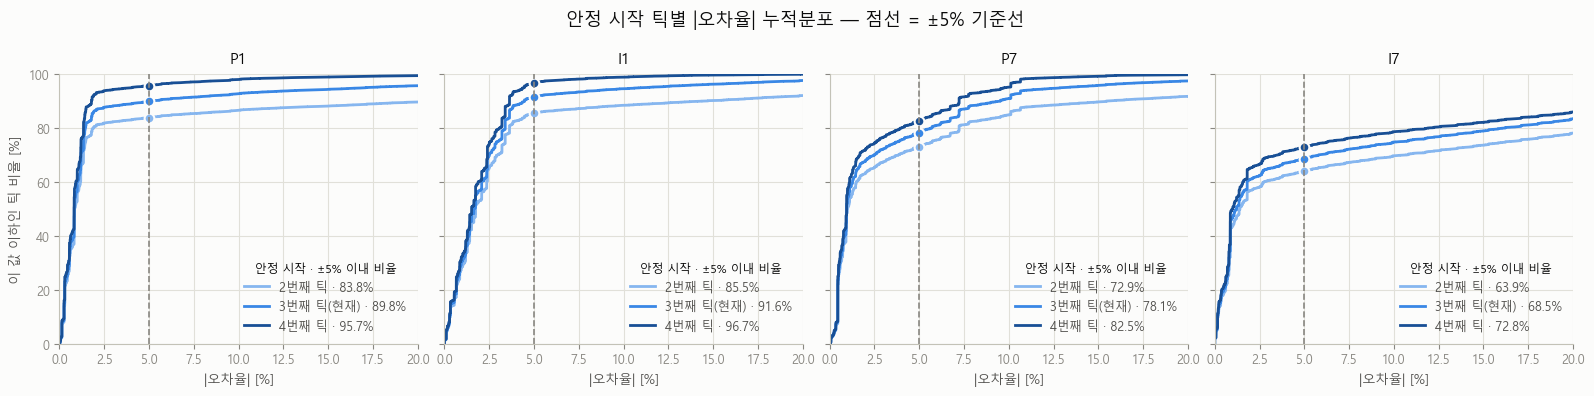

In [8]:
# |오차율| 누적분포 — 박스플롯은 꼬리를 못 보여줘서 ECDF 로 본다
fig, axes = plt.subplots(1, len(PUMP_IDS), figsize=(4 * len(PUMP_IDS), 4), sharey=True)
for ax, pid in zip(np.atleast_1d(axes), PUMP_IDS):
    tf = frames[pid]
    for (t, label), c in zip(STEADY_OPTIONS.items(), SEQ3):
        v = np.sort(tf[tf["Tick_Index"] >= t]["Err_Pct"].dropna().abs().values)
        y = np.arange(1, len(v) + 1) / len(v) * 100
        hit = (v <= 5).mean() * 100
        # 합격률은 legend 라벨에 넣는다 — 곡선 옆에 직접 달면 제목·곡선과 겹친다
        ax.plot(v, y, color=c, lw=2, label=f"{label} · {hit:.1f}%")
        ax.plot([5], [hit], "o", ms=7, color=c, mec=SURFACE, mew=1.5)
    ax.axvline(5, color=MUTED, ls="--", lw=1.2)
    ax.set_xlim(0, 20); ax.set_ylim(0, 100)
    style(ax, title=pid, xlabel="|오차율| [%]",
          ylabel="이 값 이하인 틱 비율 [%]" if pid == PUMP_IDS[0] else None)
    ax.legend(frameon=False, fontsize=9, labelcolor=INK2, loc="lower right",
              title="안정 시작 · ±5% 이내 비율", title_fontsize=8.5)
fig.suptitle("안정 시작 틱별 |오차율| 누적분포 — 점선 = ±5% 기준선", color=INK, fontsize=13)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

---## 5. SV 그룹별로 보면 — 목표가 클수록 더 부족한가행이 SV 값(레시피), 열이 안정 시작 기준이다. 칸의 숫자는 그 조합의 **평균 오차율 %**.붉을수록 유량 부족(+), 푸를수록 초과(-)다.자르는 기준은 **정의 B**(`Ticks_Since_SV_Change >= t`)를 쓴다. 정의 A 로 자르면 사이클도중에만 잠깐 나타난 SV 값이 "새 목표를 막 쫓기 시작한" 상태로 통째로 집계돼서-10% 가 넘는 가짜 그룹이 생긴다.

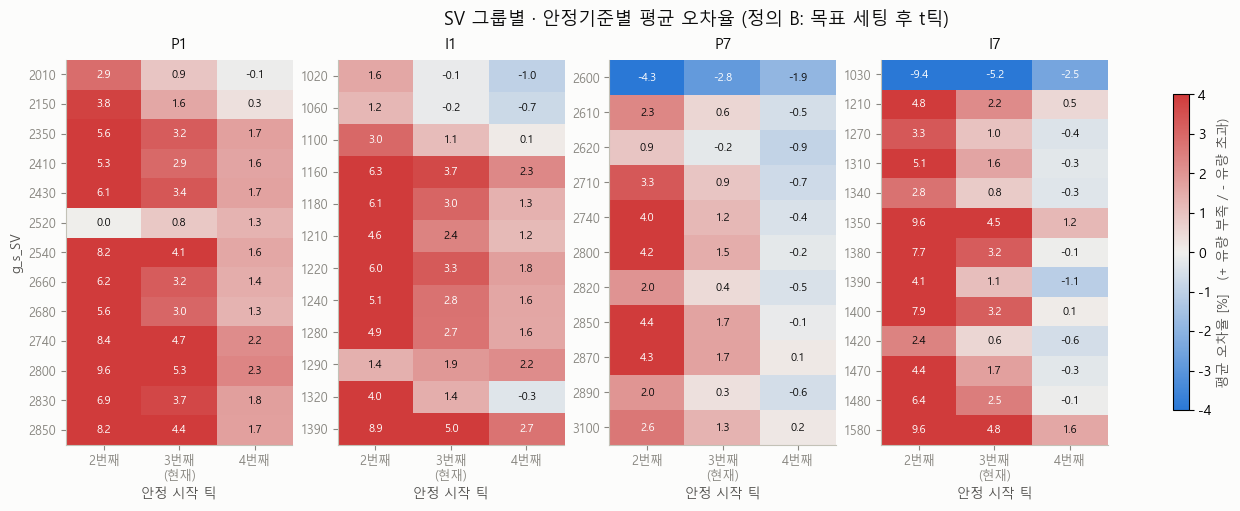

In [9]:
fig, axes = plt.subplots(1, len(PUMP_IDS), figsize=(4.2 * len(PUMP_IDS), 5))
for ax, pid in zip(np.atleast_1d(axes), PUMP_IDS):
    tf = frames[pid]
    cnt = tf[tf["Ticks_Since_SV_Change"] >= 3]["SV"].value_counts()
    levels = sorted(cnt[cnt >= MIN_TICKS_PER_SV].index)
    mat = np.array([[tf[(tf["SV"] == lv) & (tf["Ticks_Since_SV_Change"] >= t)]["Err_Pct"].mean()
                     for t in STEADY_OPTIONS] for lv in levels])
    im = ax.imshow(mat, cmap=DIVERGING, vmin=-4, vmax=4, aspect="auto")
    ax.set_xticks(range(len(STEADY_OPTIONS)), ["2번째", "3번째\n(현재)", "4번째"])
    ax.set_yticks(range(len(levels)), [str(int(v)) for v in levels])
    for i in range(len(levels)):
        for j in range(mat.shape[1]):
            if not np.isnan(mat[i, j]):
                ax.text(j, i, f"{mat[i, j]:.1f}", ha="center", va="center", fontsize=8,
                        color="#ffffff" if abs(mat[i, j]) > 2.4 else INK)
    style(ax, title=pid, xlabel="안정 시작 틱", ylabel="g_s_SV" if pid == PUMP_IDS[0] else None)
    ax.grid(False)
cb = fig.colorbar(im, ax=np.atleast_1d(axes), shrink=.82)
cb.set_label("평균 오차율 [%]   (+ 유량 부족 / - 유량 초과)", color=INK2, fontsize=9.5)
fig.suptitle("SV 그룹별 · 안정기준별 평균 오차율 (정의 B: 목표 세팅 후 t틱)", color=INK, fontsize=13)
fig.patch.set_facecolor(SURFACE)
plt.show()

### 절대값으로 보면 — 실제 유량이 목표에서 몇 g/s 떨어져 있나점 하나가 사이클 하나다. x 는 목표, y 는 그 사이클 안정구간의 평균 유량.점선 `y=x` 위에 있으면 목표 초과, 아래면 부족이다.

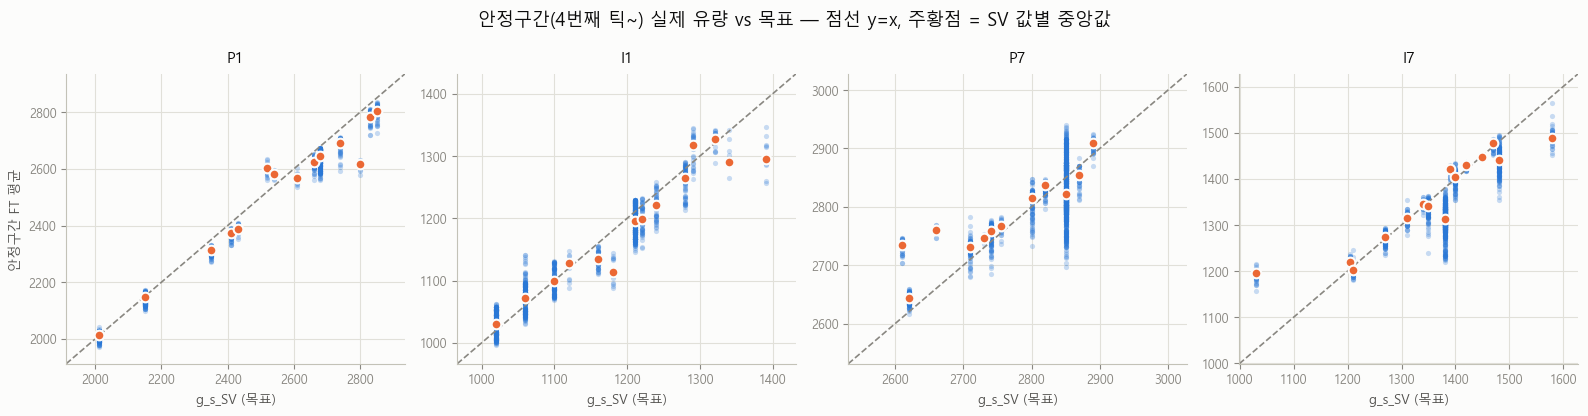

In [10]:
fig, axes = plt.subplots(1, len(PUMP_IDS), figsize=(4 * len(PUMP_IDS), 4.2))
for ax, pid in zip(np.atleast_1d(axes), PUMP_IDS):
    tf = frames[pid]
    st = tf[tf["Ticks_Since_SV_Change"] >= 3]          # 정의 B, 4번째 틱 기준
    per = st.groupby("Cycle_ID").agg(SV=("SV", "median"), FT=("FT", "mean"))
    ax.scatter(per["SV"], per["FT"], s=14, color=BLUE, alpha=.25, lw=0)
    lim = [min(per["SV"].min(), per["FT"].min()) * .97,
           max(per["SV"].max(), per["FT"].max()) * 1.03]
    ax.plot(lim, lim, color=MUTED, ls="--", lw=1.2)
    med = per.groupby("SV")["FT"].median()
    ax.plot(med.index, med.values, "o", ms=7, color=ORANGE, mec=SURFACE, mew=1.5)
    ax.set_xlim(lim); ax.set_ylim(lim)
    style(ax, title=pid, xlabel="g_s_SV (목표)",
          ylabel="안정구간 FT 평균" if pid == PUMP_IDS[0] else None)
fig.suptitle("안정구간(4번째 틱~) 실제 유량 vs 목표 — 점선 y=x, 주황점 = SV 값별 중앙값",
             color=INK, fontsize=13)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

---## 6. 정리

In [11]:
cur, nxt = STEADY_OPTIONS[2], STEADY_OPTIONS[3]

print(f"[1] 안정 시작을 3번째(현재) -> 4번째 틱으로 옮기면  (A. 사이클 기준)\n")
print(f"{'펌프':<6}{'±5% 이내':>22}{'|오차| p95':>22}{'평균 오차율':>20}")
for pid in PUMP_IDS:
    s = summary[summary["펌프"] == pid].set_index("안정 시작")
    print(f"{pid:<6}"
          f"{s.loc[cur, 'A.±5%이내']:>9.1f}% -> {s.loc[nxt, 'A.±5%이내']:>6.1f}%"
          f"{s.loc[cur, 'A.|오차|p95']:>13.1f}% -> {s.loc[nxt, 'A.|오차|p95']:>5.1f}%"
          f"{s.loc[cur, 'A.평균%']:>12.2f}% -> {s.loc[nxt, 'A.평균%']:>5.2f}%")

print(f"\n[2] 같은 4번째 틱에서, 재는 기준을 A(사이클) -> B(목표)로 바꾸면\n")
print(f"{'펌프':<6}{'±5% 이내':>22}{'|오차| p95':>22}")
for pid in PUMP_IDS:
    s = summary[summary["펌프"] == pid].set_index("안정 시작")
    print(f"{pid:<6}"
          f"{s.loc[nxt, 'A.±5%이내']:>9.1f}% -> {s.loc[nxt, 'B.±5%이내']:>6.1f}%"
          f"{s.loc[nxt, 'A.|오차|p95']:>13.1f}% -> {s.loc[nxt, 'B.|오차|p95']:>5.1f}%")

[1] 안정 시작을 3번째(현재) -> 4번째 틱으로 옮기면  (A. 사이클 기준)

펌프                    ±5% 이내              |오차| p95              평균 오차율
P1         89.8% ->   95.7%         17.4% ->   4.1%        2.48% ->  0.98%
I1         91.6% ->   96.7%         11.4% ->   4.5%        1.44% ->  0.40%
P7         78.1% ->   82.5%         13.4% ->   9.9%        0.62% -> -0.46%
I7         68.5% ->   72.8%         33.2% ->  31.6%        0.18% -> -1.38%

[2] 같은 4번째 틱에서, 재는 기준을 A(사이클) -> B(목표)로 바꾸면

펌프                    ±5% 이내              |오차| p95
P1         95.7% ->   96.7%          4.1% ->   2.5%
I1         96.7% ->   97.6%          4.5% ->   4.2%
P7         82.5% ->   96.8%          9.9% ->   3.6%
I7         72.8% ->   92.4%         31.6% ->   7.1%


**읽은 결과**1. **3번째 틱은 아직 증압 중이다.** 틱별 프로파일에서 `Tick_Index=2`(3번째 틱)의 중앙값   오차가 아직 10~20% 대이고, `Tick_Index=3`(4번째 틱)에서 비로소 0% 근처로 떨어진다.   지금의 `STEADY_TICK_MIN=2` 는 증압 꼬리를 한 틱 물고 있다.2. **중앙값은 안 변하고 꼬리만 변한다.** 세 기준 모두 중앙값 오차는 1% 안쪽으로 같다.   달라지는 건 `|오차| p95` 다 — 기준을 한 틱 늦추면 이 값이 크게 줄어든다. 즉   `Steady_Std_FT`, `Instant_FT_Error_Rate_*` 같은 **산포 기반 피처가 증압 잔재에   오염되고 있었다**는 뜻이다.3. **SV 도중 변경이 두 번째 오염원이다.** 펌프에 따라 사이클의 절반 이상에서 다음 샷의   SV 가 미리 들어오고, 그 직후 몇 틱은 새 목표를 다시 쫓는 구간이라 안정구간이 아니다.   같은 4번째 틱이라도 재는 기준을 A(사이클 시작 기준)에서 B(목표 세팅 기준)로 바꾸면   합격률이 한 번 더 오른다 — 특히 도중 변경이 잦은 P7/I7 에서 차이가 크다.4. **정상 상태의 실제 추종 성능은 ±1~2%** 다. 목표에 들어온 뒤의 유량은 `g_s_SV` 대비   평균 1~2% 부족한 선에서 유지되고, 높은 SV 레시피일수록 부족분이 조금씩 커진다   (히트맵에서 아래로 갈수록 붉어지는 경향).**피처 쪽에 반영한다면** — `STEADY_TICK_MIN` 을 3으로 올리고, 안정구간 판정을`Tick_Index` 대신 `Ticks_Since_SV_Change` 로 바꾸는 것(A→B)이 근거 있는 수정이다. 다만 이건**이상탐지 성능으로 검증한 게 아니라 신호 모양으로만 확인한 것**이므로,바꾸기 전에 `Cycle_AE_v3` 재학습으로 이상률이 어떻게 변하는지 봐야 한다.